<a href="https://colab.research.google.com/github/sundarbee/PythonWorkout/blob/main/DeepLearning_With_Hyperparameter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [83]:
#regression problem
# About housing dataset
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from keras.optimizers import Adam

In [2]:
# load the data
url = 'https://raw.githubusercontent.com/ziafaq/genai/refs/heads/main/housing.csv'
df = pd.read_csv(url)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [15]:
df_copy = df.copy()
df_copy.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [3]:
df.shape

(20640, 10)

In [9]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [10]:
# fill Missing Value
medium_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms'].fillna(medium_bedrooms, inplace=True)


/tmp/ipython-input-111116461.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_bedrooms'].fillna(medium_bedrooms, inplace=True)


In [11]:
df.isna().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [13]:
df['ocean_proximity'].nunique()

5

In [12]:
df['ocean_proximity'].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [23]:
if 'ocean_proximity' in df.columns:
    df = pd.get_dummies(df, columns=['ocean_proximity'], dtype='int')
    print("Column 'ocean_proximity' successfully one-hot encoded.")
else:
    print("Column 'ocean_proximity' not found. It might have been processed already.")
df.head()

Column 'ocean_proximity' not found. It might have been processed already.


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,False,True,False


In [24]:
for col in df.columns:
    if col.startswith('ocean_proximity_'):
        df[col] = df[col].astype(int)

print("Data types after converting 'ocean_proximity' columns to integer:")
display(df.dtypes)

Data types after converting 'ocean_proximity' columns to integer:


,0
longitude,float64
latitude,float64
housing_median_age,float64
total_rooms,float64
total_bedrooms,float64
population,float64
households,float64
median_income,float64
median_house_value,float64
ocean_proximity_<1H OCEAN,int64


In [25]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [30]:
X= df.drop('median_house_value', axis=1)
y= df['median_house_value']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train,X_test,y_train,y_test)

       longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
14196    -117.03     32.71                33.0       3126.0           627.0   
8267     -118.16     33.77                49.0       3382.0           787.0   
17445    -120.48     34.66                 4.0       1897.0           331.0   
14265    -117.11     32.69                36.0       1421.0           367.0   
2271     -119.80     36.78                43.0       2382.0           431.0   
...          ...       ...                 ...          ...             ...   
11284    -117.96     33.78                35.0       1330.0           201.0   
11964    -117.43     34.02                33.0       3084.0           570.0   
5390     -118.38     34.03                36.0       2101.0           569.0   
860      -121.96     37.58                15.0       3575.0           597.0   
15795    -122.42     37.77                52.0       4226.0          1315.0   

       population  households  median_income  ocean

In [32]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),columns=X_test.columns)
print(X_train_scaled.head(1))

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0   1.272587 -1.372811             0.34849     0.222569        0.211228   

   population  households  median_income  ocean_proximity_<1H OCEAN  \
0    0.768276    0.322906      -0.326196                  -0.894683   

   ocean_proximity_INLAND  ocean_proximity_ISLAND  ocean_proximity_NEAR BAY  \
0               -0.680574               -0.015566                 -0.355646   

   ocean_proximity_NEAR OCEAN  
0                    2.629758  


In [36]:

lr = LinearRegression()
lr.fit(X_train_scaled,y_train)

LinearRegression()

In [37]:
results = pd.DataFrame(columns=['Model', 'MSE', 'R2','Params'])
results

,Model,MSE,R2,Params


In [46]:
def record_result(model, params_info):
  y_pred = model.predict(X_test_scaled)
  mse = mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  print(f'MSE: {mse}')
  print(f'R2: {r2}')
  results.loc[len(results)] = { 'Model': model, 'MSE': mse, 'R2' : r2, 'Params': params_info }

In [47]:
paraminf = "scaled"
record_result(lr,paraminf)
display(results)

MSE: 4908476721.156616
R2: 0.6254240620553606


,Model,MSE,R2,Params
0,LinearRegression(),4.908477e+09,0.625424,scaled
1,LinearRegression(),4.908477e+09,0.625424,scaled


In [51]:
from keras.models import Sequential
from keras.layers import Dense,Input

In [52]:
X_train_scaled.shape

(16512, 13)

In [69]:
model = Sequential()
model.add(Input(shape=(X_train_scaled.shape[1],)))
model.add(Dense(16))
model.add(Dense(8))

model.add(Dense(1))

# compile the model
model.compile(loss='mean_squared_error',metrics=['mse'])
model.summary()



Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
!pip install keras_visualizer

In [70]:
import keras_visualizer
keras_visualizer.visualizer(model, file_name='test',file_format='png')

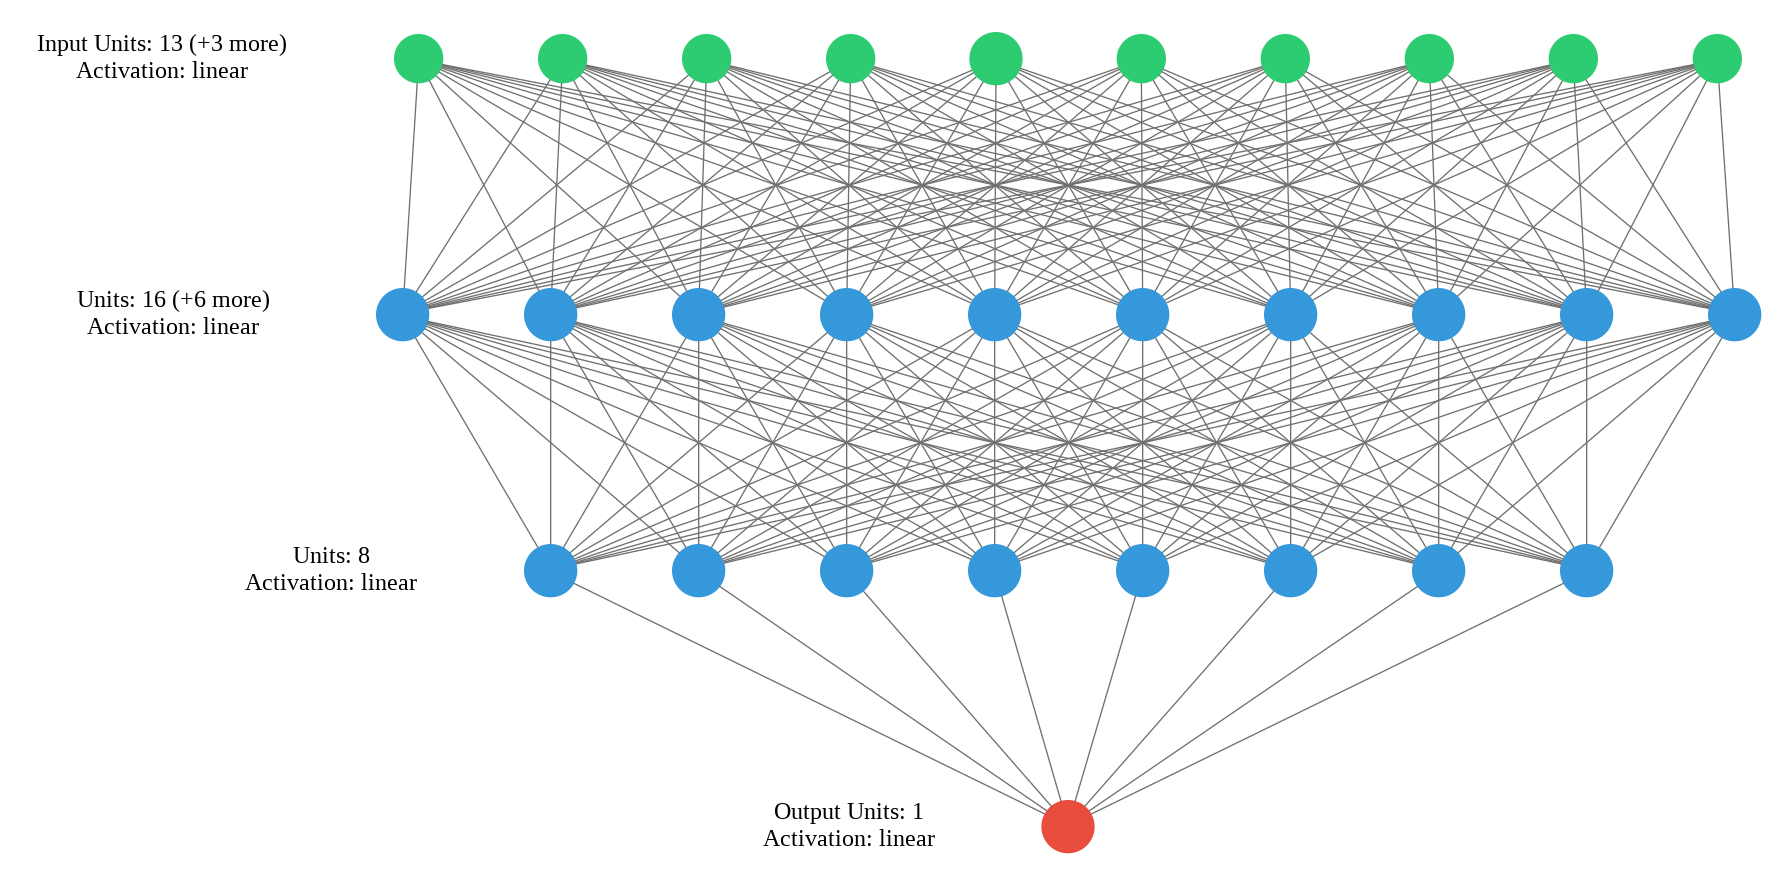

In [71]:
from IPython.display import Image, display

# Replace 'your_image.png' with the actual filename
display(Image('test.png'))

In [72]:
# train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 56706863104.0000 - mse: 56706863104.0000 - val_loss: 56855670784.0000 - val_mse: 56855670784.0000
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 57013567488.0000 - mse: 57013567488.0000 - val_loss: 56782057472.0000 - val_mse: 56782057472.0000
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 56455188480.0000 - mse: 56455188480.0000 - val_loss: 56615301120.0000 - val_mse: 56615301120.0000
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 55652102144.0000 - mse: 55652102144.0000 - val_loss: 56322232320.0000 - val_mse: 56322232320.0000
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 56205918208.0000 - mse: 56205918208.0000 - val_loss: 55866327040.0000 - val_mse: 55866327040.0000
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 56038785024.0000 - mse: 56038785024.0000 - val_loss: 55222534144.0000 - val_mse: 55222534144.0000
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step 

In [75]:
import matplotlib.pyplot as plt

def plot_history(history):
  plt.plot(model.history.history['loss'])
  plt.plot(model.history.history['val_loss'])
  plt.title('model loss')
  plt.ylabel('loss')
  plt.xlabel('epoch')

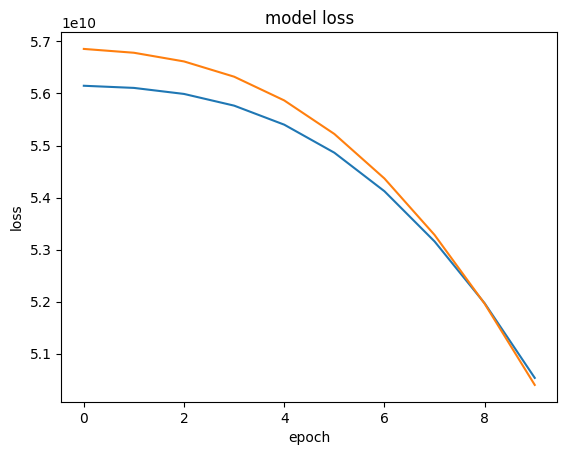

In [76]:
plot_history(history)

In [77]:
paraminf = "13-ip,16-m,8-n,lss=mse,met=mse,10epohs,32 batch size"
record_result(model,paraminf)
display(results)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MSE: 49109678085.76283
R2: -2.747660379409788


,Model,MSE,R2,Params
0,LinearRegression(),4.908477e+09,0.625424,scaled
1,LinearRegression(),4.908477e+09,0.625424,scaled
2,"<Sequential name=sequential, built=True>",3.663372e+10,-1.795594,"13-ip,16-m,8-n,lss=mse,met=mse,10epohs,32 batc..."
3,"<Sequential name=sequential_4, built=True>",3.378888e+10,-1.578499,"13-ip,16-m,8-n,act = RELU,lss=mse,met=mse,10ep..."
4,"<Sequential name=sequential_6, built=True>",4.910968e+10,-2.747660,"13-ip,16-m,8-n,lss=mse,met=mse,10epohs,32 batc..."


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 369 (1.44 KB)

 Trainable params: 369 (1.44 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 56353718272.0000 - mse: 56353718272.0000 - val_loss: 56823042048.0000 - val_mse: 56823042048.0000
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56382853120.0000 - mse: 56382853120.0000 - val_loss: 56490954752.0000 - val_mse: 56490954752.0000
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54989377536.0000 - mse: 54989377536.0000 - val_loss: 55671369728.0000 - val_mse: 55671369728.0000
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 54538838016.0000 - mse: 54538838016.0000 - val_loss: 54259986432.0000 - val_mse: 54259986432.0000
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 53665271808.0000 - mse: 53665271808.0000 - val_loss: 52231995392.0000 - val_mse: 52231995392.0000
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 50887860224.0000 - mse: 50887860224.0000 - val_loss: 49614499840.0000 - val_mse: 49614499840.0000
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step 

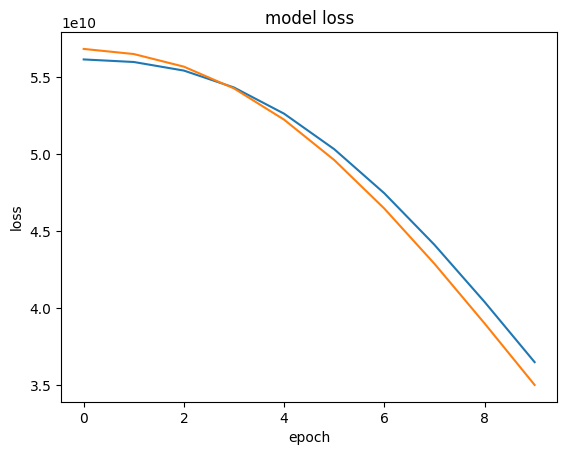

In [66]:
model = Sequential()
model.add(Input(shape=(X_train_scaled.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))

model.add(Dense(1, activation='linear'))

# compile the model
model.compile(optimizer='adam', loss='mean_squared_error',metrics=['mse'])
model.summary()

# train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
plot_history(history)

In [67]:
paraminf = "13-ip,16-m,8-n,act = RELU,lss=mse,met=mse,10epohs,32 batch size"
record_result(model,paraminf)
display(results)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
MSE: 33788881221.796535
R2: -1.578498910100182


,Model,MSE,R2,Params
0,LinearRegression(),4.908477e+09,0.625424,scaled
1,LinearRegression(),4.908477e+09,0.625424,scaled
2,"<Sequential name=sequential, built=True>",3.663372e+10,-1.795594,"13-ip,16-m,8-n,lss=mse,met=mse,10epohs,32 batc..."
3,"<Sequential name=sequential_4, built=True>",3.378888e+10,-1.578499,"13-ip,16-m,8-n,act = RELU,lss=mse,met=mse,10ep..."


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 56070676480.0000 - mse: 56070676480.0000 - val_loss: 56419319808.0000 - val_mse: 56419319808.0000
Epoch 2/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56019058688.0000 - mse: 56019058688.0000 - val_loss: 53253214208.0000 - val_mse: 53253214208.0000
Epoch 3/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 51191099392.0000 - mse: 51191099392.0000 - val_loss: 46054494208.0000 - val_mse: 46054494208.0000
Epoch 4/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 42788188160.0000 - mse: 42788188160.0000 - val_loss: 35917213696.0000 - val_mse: 35917213696.0000
Epoch 5/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 32302624768.0000 - mse: 32302624768.0000 - val_loss: 25505845248.0000 - val_mse: 25505845248.0000
Epoch 6/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 23245539328.0000 - mse: 23245539328.0000 - val_loss: 17732718592.0000 - val_mse: 17732718592.0000
Epoch 7/10
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step 

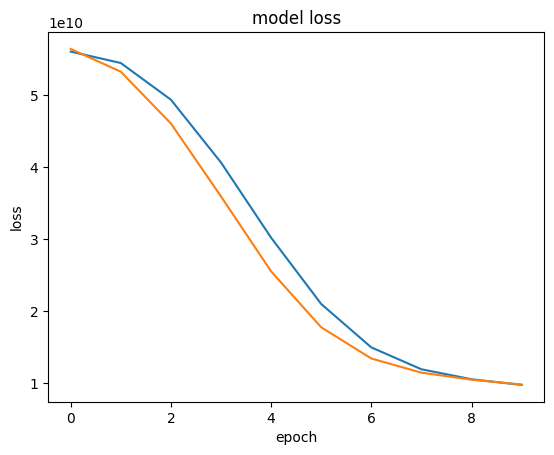

In [78]:
model = Sequential()
model.add(Input(shape=(X_train_scaled.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='linear'))

# compile the model
model.compile(optimizer='adam', loss='mean_squared_error',metrics=['mse'])
model.summary()

# train the model
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
plot_history(history)

In [80]:
paraminf = "13-ip,64-m,32-n,optimizer = ADAM, act = RELU,lss=mse,met=mse,10epohs,32 batch size"
record_result(model,paraminf)
display(results)

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MSE: 9467708478.862896
R2: 0.2774997244316504


,Model,MSE,R2,Params
0,LinearRegression(),4.908477e+09,0.625424,scaled
1,LinearRegression(),4.908477e+09,0.625424,scaled
2,"<Sequential name=sequential, built=True>",3.663372e+10,-1.795594,"13-ip,16-m,8-n,lss=mse,met=mse,10epohs,32 batc..."
3,"<Sequential name=sequential_4, built=True>",3.378888e+10,-1.578499,"13-ip,16-m,8-n,act = RELU,lss=mse,met=mse,10ep..."
4,"<Sequential name=sequential_6, built=True>",4.910968e+10,-2.747660,"13-ip,16-m,8-n,lss=mse,met=mse,10epohs,32 batc..."
5,"<Sequential name=sequential_7, built=True>",9.467708e+09,0.277500,"13-ip,16-m,8-n,act = RELU,lss=mse,met=mse,10ep..."
6,"<Sequential name=sequential_7, built=True>",9.467708e+09,0.277500,"13-ip,64-m,32-n,optimizer = ADAM, act = RELU,l..."


In [88]:
#build model
model = Sequential()

model.add(Input(shape=(X_train_scaled.shape[1],)))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(1, activation='linear'))

#compile the model
model.compile(optimizer=Adam(learning_rate=0.01),
              loss='mean_squared_error',
    metrics=['mse'])

print(model.summary())

# Train the model
history = model.fit(
    X_train_scaled,y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)



Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_33 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 45859094528.0000 - mse: 45859094528.0000 - val_loss: 8225385472.0000 - val_mse: 8225385472.0000
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 7216752640.0000 - mse: 7216752640.0000 - val_loss: 5707083776.0000 - val_mse: 5707083776.0000
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5300875776.0000 - mse: 5300875776.0000 - val_loss: 5075568640.0000 - val_mse: 5075568640.0000
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4810394624.0000 - mse: 4810394624.0000 - val_loss: 4874747904.0000 - val_mse: 4874747904.0000
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4558782464.0000 - mse: 4558782464.0000 - val_loss: 4782280704.0000 - val_mse: 4782280704.0000
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4567337984.0000 - mse: 4567337984.0000 - val_loss: 4706825216.0000 - val_mse: 4706825216.0000
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 443510323

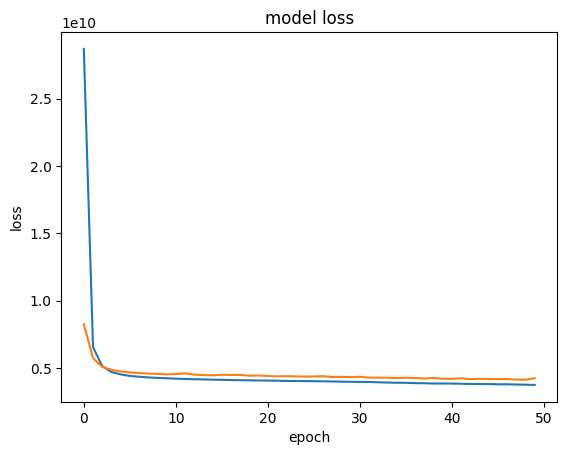

In [85]:
plot_history(history)

In [87]:
paraminf = "13-ip, 64-n, 32-n, act-relu, opt-adam-lr0.01, lss-mse met-mse, 50-ep, 32-bs"
record_result(model,paraminf)
display(results)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
MSE: 4062007839.5735345
R2: 0.6900198405976739


,Model,MSE,R2,Params
0,LinearRegression(),4.908477e+09,0.625424,scaled
1,LinearRegression(),4.908477e+09,0.625424,scaled
2,"<Sequential name=sequential, built=True>",3.663372e+10,-1.795594,"13-ip,16-m,8-n,lss=mse,met=mse,10epohs,32 batc..."
3,"<Sequential name=sequential_4, built=True>",3.378888e+10,-1.578499,"13-ip,16-m,8-n,act = RELU,lss=mse,met=mse,10ep..."
4,"<Sequential name=sequential_6, built=True>",4.910968e+10,-2.747660,"13-ip,16-m,8-n,lss=mse,met=mse,10epohs,32 batc..."
5,"<Sequential name=sequential_7, built=True>",9.467708e+09,0.277500,"13-ip,16-m,8-n,act = RELU,lss=mse,met=mse,10ep..."
6,"<Sequential name=sequential_7, built=True>",9.467708e+09,0.277500,"13-ip,64-m,32-n,optimizer = ADAM, act = RELU,l..."
7,"<Sequential name=sequential_10, built=True>",4.062008e+09,0.690020,"13-ip,64-m,32-n,optimizer = ADAM, act = RELU,l..."
8,"<Sequential name=sequential_10, built=True>",4.062008e+09,0.690020,"13-ip, 64-n, 32-n, act-relu, opt-adam-lr0.01, ..."
